In [47]:
"""
Gateway Placement Optimization — scaffold
==========================================
Separate notebook. Loads the already-fitted path-loss + GPR pipelines for
BOTH RSSI and SNR and evaluates candidate gateway positions for coverage.

"Reliable coverage" = RSSI > -105 dBm AND SNR > -3 dB, both required at
once (see RSSI_THRESHOLD_DBM / SNR_THRESHOLD_DB below).

Structure:
  1. Load model artifacts (RSSI model, SNR model, shared coordinate scaler)
  2. Define greenhouse boundary + dense uniform evaluation grid
  3. Prediction functions: candidate gateway position -> RSSI mean/std AND
     SNR mean/std at every grid point
  4. Coverage function: dual RSSI+SNR threshold (+ uncertainty margin)
  5. Single-gateway ranking
  6. Greedy multi-gateway selection (RSSI-driven best-server logic, SNR
     follows the winning gateway) + multi-restart sensitivity check
  7. Plotting: gateway placement + per-gateway coverage area
  8. Optimal placement search: hexagonal covering lattice (Kershner 1939 —
     the provably-optimal regular arrangement for covering a plane with
     congruent circles at minimum overlap) + Lloyd's relaxation to adapt
     it to the finite greenhouse footprint, pruned/validated against the
     real fitted model rather than the idealized circle
"""

# -----------------------------------------------------------------------
# Still open:
#   - Fill in the real greenhouse boundary polygon if it isn't a plain
#     rectangle (currently just X_MIN/X_MAX/Y_MIN/Y_MAX + central-path
#     exclusion — see make_evaluation_grid's TODO)
#   - Section 8 (hex lattice + Lloyd's relaxation) proposes NEW candidate
#     positions from scratch instead of picking from a fixed list — once
#     you have real candidate coordinates from teammates, compare them
#     against section 8's output rather than replacing it outright.
#   - EVAL_RESOLUTION=1.0 over the full greenhouse is ~90k+ points; GPR
#     predict(..., return_std=True) cost scales with n_train^2 * n_test,
#     so rank_single_gateways / greedy over many real candidates at full
#     resolution could get slow. Worth profiling once real candidates
#     exist — if needed, coarsen EVAL_RESOLUTION for the search and only
#     re-evaluate the winner at full resolution for the report figure.
#     (Section 8 already does this: coarse grid for the lattice search,
#     full eval_grid only for the final validation/plot.)
# -----------------------------------------------------------------------

'\nGateway Placement Optimization — scaffold\n==========================================\nSeparate notebook. Loads the already-fitted path-loss + GPR pipelines for\nBOTH RSSI and SNR and evaluates candidate gateway positions for coverage.\n\n"Reliable coverage" = RSSI > -105 dBm AND SNR > -3 dB, both required at\nonce (see RSSI_THRESHOLD_DBM / SNR_THRESHOLD_DB below).\n\nStructure:\n  1. Load model artifacts (RSSI model, SNR model, shared coordinate scaler)\n  2. Define greenhouse boundary + dense uniform evaluation grid\n  3. Prediction functions: candidate gateway position -> RSSI mean/std AND\n     SNR mean/std at every grid point\n  4. Coverage function: dual RSSI+SNR threshold (+ uncertainty margin)\n  5. Single-gateway ranking\n  6. Greedy multi-gateway selection (RSSI-driven best-server logic, SNR\n     follows the winning gateway) + multi-restart sensitivity check\n  7. Plotting: gateway placement + per-gateway coverage area\n  8. Optimal placement search: hexagonal covering la

In [48]:
import numpy as np
import pandas as pd
import joblib
from scipy.spatial.distance import cdist

# "Reliable coverage" thresholds
RSSI_THRESHOLD_DBM = -105
SNR_THRESHOLD_DB = -3

## 1. Load Model artifacts

In [49]:
MODEL_DIR = "."  # adjust to wherever the .pkl files live

# Coordinate scaler is shared, both RSSI and SNR GPR were fitted on the same
coord_scaler = joblib.load(f"{MODEL_DIR}/coord_scaler_full_dataset.pkl")

# RSSI: the retained/final heteroscedastic GPR candidate
rssi_gpr_model = joblib.load(f"{MODEL_DIR}/gpr_hetero_final_candidate.pkl")
rssi_pathloss_coeffs = joblib.load(f"{MODEL_DIR}/pathloss_coeffs_full_dataset.pkl")

# SNR
snr_gpr_model = joblib.load(f"{MODEL_DIR}/gpr_hetero_snr_final_candidate.pkl")
snr_pathloss_coeffs = joblib.load(f"{MODEL_DIR}/pathloss_coeffs_snr_full_dataset.pkl")

print('RSSI pathloss coeffs [intercept, log10_slope, crossing_slope]:', rssi_pathloss_coeffs)
print('SNR  pathloss coeffs [intercept, log10_slope, crossing_slope]:', snr_pathloss_coeffs)


RSSI pathloss coeffs [intercept, log10_slope, crossing_slope]: [-2.70046516e+01 -3.53681475e+01 -2.45044739e-02]
SNR  pathloss coeffs [intercept, log10_slope, crossing_slope]: [ 26.18767807 -10.18908797  -0.06653518]


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 2. Greenhouse boundary and dense evaluation grid

In [50]:
diff_units = 1.1 / 1.65
X_MIN, X_MAX = -162.0, 162.0    # along rows
Y_MIN, Y_MAX = -138.6 * diff_units, 305.25 * diff_units    # across rows
EVAL_RESOLUTION = 1.0           # meters between evaluation points

ROW_SPACING = 1.1

# Central path (middle point is x 0)
CENTRAL_PATH_X_MIN, CENTRAL_PATH_X_MAX = -2.0, 2.0  


# DENSER EVALUATION GRID
def make_evaluation_grid(x_min, x_max, y_min, y_max, resolution,
                          exclude_x_range=None):
    
    # exclude_x_range: optional, we did it for the central path corridor
    xs = np.arange(x_min, x_max + resolution, resolution)
    ys = np.arange(y_min, y_max + resolution, resolution)
    xx, yy = np.meshgrid(xs, ys)
    grid_df = pd.DataFrame({"x": xx.ravel(), "y": yy.ravel()})

    if exclude_x_range is not None:
        low, high = exclude_x_range
        grid_df = grid_df[~grid_df["x"].between(low, high)].reset_index(drop=True)
    return grid_df


eval_grid = make_evaluation_grid(
    X_MIN, X_MAX, Y_MIN, Y_MAX, EVAL_RESOLUTION,
    exclude_x_range=(CENTRAL_PATH_X_MIN, CENTRAL_PATH_X_MAX),
)

In [51]:
# Medium-resolution grid for section 8/9's post-search validation + plots.
# GPR predict(..., return_std=True) cost scales with n_train^2 * n_test, so
# checking many gateways against the full 1 m eval_grid (~140k points at
# the current boundary) is too slow once a search returns more than a
# handful of gateways. 2.5 m keeps the coverage-% estimate precise
# (binomial SE well under 1%) and the plots visually smooth, at a fraction
# of the cost.
REPORT_RESOLUTION = 2.5
report_grid = make_evaluation_grid(
    X_MIN, X_MAX, Y_MIN, Y_MAX, REPORT_RESOLUTION,
    exclude_x_range=(CENTRAL_PATH_X_MIN, CENTRAL_PATH_X_MAX),
)
print(f"report_grid: {len(report_grid)} points (vs {len(eval_grid)} in the full eval_grid)")

report_grid: 15480 points (vs 95040 in the full eval_grid)


## 3. make predictions for given gateway position

In [52]:
def compute_distance_and_crossings(points_df, gw_x, gw_y, row_spacing=ROW_SPACING):
    # Recompute distance + row_crossings from a candidate gateway position to every point
    dx = points_df["x"].values - gw_x
    dy = points_df["y"].values - gw_y
    distance = np.sqrt(dx**2 + dy**2)

    row_crossings = np.round(np.abs(dy) / row_spacing).astype(int)

    return distance, row_crossings


def pathloss_prediction(distance, row_crossings, coeffs):
    """
    coeffs is the raw lstsq coefficient array [intercept, log10_slope,
    crossing_slope] saved as pathloss_coeffs_*_full_dataset.pkl
    """
    intercept, log10_slope, crossing_slope = coeffs
    return (
        intercept
        + log10_slope * np.log10(np.maximum(distance, 1e-3))
        + crossing_slope * row_crossings
    )


def predict_signal_for_gateway(gw_x, gw_y, eval_grid, gpr_model, pathloss_coeffs, coord_scaler):
    """
    Full two-stage prediction (path-loss + GPR residual correction) at
    every evaluation grid point, for ONE target (RSSI or SNR)
    """
    distance, row_crossings = compute_distance_and_crossings(eval_grid, gw_x, gw_y)
    pl_pred = pathloss_prediction(distance, row_crossings, pathloss_coeffs)

    coords_scaled = coord_scaler.transform(eval_grid[["x", "y"]].values)
    residual_mean, residual_std = gpr_model.predict(coords_scaled, return_std=True)

    predicted_mean = pl_pred + residual_mean
    predicted_std = residual_std  # heteroscedastic noise already reflected here

    return predicted_mean, predicted_std


def predict_rssi_snr_for_gateway(gw_x, gw_y, eval_grid):
    """
    Both targets at once, returns (rssi_mean, rssi_std, snr_mean, snr_std).
    """
    rssi_mean, rssi_std = predict_signal_for_gateway(
        gw_x, gw_y, eval_grid, rssi_gpr_model, rssi_pathloss_coeffs, coord_scaler
    )
    snr_mean, snr_std = predict_signal_for_gateway(
        gw_x, gw_y, eval_grid, snr_gpr_model, snr_pathloss_coeffs, coord_scaler
    )
    return rssi_mean, rssi_std, snr_mean, snr_std

## 4. Coverage function (threshold + uncertainty margin)

In [53]:
def coverage_mask(rssi_mean, rssi_std, snr_mean, snr_std,
                   rssi_threshold=RSSI_THRESHOLD_DBM,
                   snr_threshold=SNR_THRESHOLD_DB, z=1.645):
    """
    A point counts as "reliably covered" only if BOTH hold: RSSI strong
    enough to be detected AND SNR high enough to demodulate. 
    Each check uses a (mean - z*std) confidence bound on its own metric
    (z=1.645 -> ~ 95%).
    """
    rssi_ok = (rssi_mean - z * rssi_std) > rssi_threshold
    snr_ok = (snr_mean - z * snr_std) > snr_threshold
    return rssi_ok & snr_ok

## 5. Rank each gateway candiate

In [54]:
def rank_single_gateways(candidates_df, eval_grid,
                          rssi_threshold=RSSI_THRESHOLD_DBM,
                          snr_threshold=SNR_THRESHOLD_DB, z=1.645):
    """
    candidates_df: DataFrame with columns ['candidate_id', 'x', 'y']
    Returns candidates_df with an extra 'coverage_pct' column, and rank them
    """
    results = []
    for _, row in candidates_df.iterrows():
        rssi_mean, rssi_std, snr_mean, snr_std = predict_rssi_snr_for_gateway(
            row["x"], row["y"], eval_grid
        )
        covered = coverage_mask(rssi_mean, rssi_std, snr_mean, snr_std,
                                 rssi_threshold, snr_threshold, z=z)
        results.append(covered.mean())

    out = candidates_df.copy()
    out["coverage_pct"] = results
    return out.sort_values("coverage_pct", ascending=False).reset_index(drop=True)

## 6. Greedy gateway selection

In [55]:
def greedy_gateway_selection(candidates_df, eval_grid,
                              rssi_threshold=RSSI_THRESHOLD_DBM,
                              snr_threshold=SNR_THRESHOLD_DB,
                              max_gateways=5, min_marginal_gain=0.01, z=1.645,
                              forced_first_id=None, cache=None, verbose=True):
    """
    Iteratively adds the candidate that covers the most currently-uncovered
    grid points. "Best server" per point is whichever selected gateway
    gives the strongest RSSI there (the one a device would actually attach
    to) — that gateway's SNR travels with it, RSSI and SNR are never mixed
    from two different gateways at the same point. Stops at max_gateways or
    when marginal gain drops below min_marginal_gain (fraction of total
    grid points).

    forced_first_id: if given, that candidate is used unconditionally as
    step 1 — used by multi_restart_greedy to test sensitivity to the
    starting choice.
    cache: optional {candidate_id: (rssi_mean, rssi_std, snr_mean, snr_std)}
    to reuse predictions across repeated calls (e.g. multiple restarts)
    instead of recomputing them every time.
    """
    n_points = len(eval_grid)

    if cache is None:
        cache = {}
        for _, row in candidates_df.iterrows():
            cache[row["candidate_id"]] = predict_rssi_snr_for_gateway(
                row["x"], row["y"], eval_grid
            )

    best_rssi_mean_so_far = np.full(n_points, -np.inf)
    best_rssi_std_so_far = np.zeros(n_points)
    best_snr_mean_so_far = np.full(n_points, -np.inf)
    best_snr_std_so_far = np.zeros(n_points)
    covered_so_far = np.zeros(n_points, dtype=bool)

    selected = []
    remaining = candidates_df.copy()

    for step in range(max_gateways):
        if step == 0 and forced_first_id is not None:
            candidate_ids = [forced_first_id]
        else:
            candidate_ids = remaining["candidate_id"].tolist()

        best_gain = -1
        best_id = None
        best_state = None

        for cand_id in candidate_ids:
            rssi_mean, rssi_std, snr_mean, snr_std = cache[cand_id]

            # "Best server" switch decided by RSSI only; SNR follows
            # whichever gateway wins at each point (never independently
            # maxed from a different gateway than the RSSI winner).
            switch = rssi_mean > best_rssi_mean_so_far
            tentative_rssi_mean = np.where(switch, rssi_mean, best_rssi_mean_so_far)
            tentative_rssi_std = np.where(switch, rssi_std, best_rssi_std_so_far)
            tentative_snr_mean = np.where(switch, snr_mean, best_snr_mean_so_far)
            tentative_snr_std = np.where(switch, snr_std, best_snr_std_so_far)

            tentative_covered = coverage_mask(
                tentative_rssi_mean, tentative_rssi_std,
                tentative_snr_mean, tentative_snr_std,
                rssi_threshold, snr_threshold, z=z,
            )
            gain = (tentative_covered & ~covered_so_far).sum() / n_points

            if gain > best_gain:
                best_gain = gain
                best_id = cand_id
                best_state = (tentative_rssi_mean, tentative_rssi_std,
                               tentative_snr_mean, tentative_snr_std, tentative_covered)

        if best_id is None or best_gain < min_marginal_gain:
            if verbose:
                print(f"Stopping: marginal gain {best_gain:.3%} below threshold "
                      f"{min_marginal_gain:.3%} (or no candidates left).")
            break

        selected.append(best_id)
        (best_rssi_mean_so_far, best_rssi_std_so_far,
         best_snr_mean_so_far, best_snr_std_so_far, covered_so_far) = best_state
        remaining = remaining[remaining["candidate_id"] != best_id]

        total_coverage = covered_so_far.mean()
        if verbose:
            print(f"Step {step+1}: added gateway {best_id} "
                  f"(+{best_gain:.1%} marginal) -> total coverage {total_coverage:.1%}")

        if total_coverage >= 0.999:
            if verbose:
                print("Reached ~100% coverage.")
            break

    return selected, covered_so_far, (best_rssi_mean_so_far, best_rssi_std_so_far,
                                        best_snr_mean_so_far, best_snr_std_so_far)

In [56]:
# TODO: pittfalls of greedy:
        # - multiple restarts
        # - integer linear programming

## 6.b multi restart greedy

In [57]:
def multi_restart_greedy(candidates_df, eval_grid,
                          rssi_threshold=RSSI_THRESHOLD_DBM,
                          snr_threshold=SNR_THRESHOLD_DB,
                          n_restarts=5, max_gateways=8, min_marginal_gain=0.01, z=1.645):
    """
    Runs greedy_gateway_selection once per top-N single-gateway starting
    candidate (by standalone coverage), forcing each as step 1, and compares
    how many gateways each restart needs to reach full/near-full coverage.

    This checks exactly the failure mode where the single best standalone
    gateway isn't part of the true minimal covering set — if restarts
    disagree on gateway count, greedy's "unforced" answer may not be optimal.

    Returns a summary DataFrame plus a dict of {start_id: (selected, covered, signal)}.
    """
    # Precompute predictions once, shared across every restart
    cache = {}
    for _, row in candidates_df.iterrows():
        cache[row["candidate_id"]] = predict_rssi_snr_for_gateway(row["x"], row["y"], eval_grid)

    # Rank candidates by standalone coverage to pick restart starting points
    ranked = rank_single_gateways(candidates_df, eval_grid, rssi_threshold, snr_threshold, z=z)
    start_ids = ranked["candidate_id"].head(n_restarts).tolist()

    summary_rows = []
    full_results = {}

    for start_id in start_ids:
        selected, covered, signal = greedy_gateway_selection(
            candidates_df, eval_grid, rssi_threshold, snr_threshold,
            max_gateways=max_gateways, min_marginal_gain=min_marginal_gain, z=z,
            forced_first_id=start_id, cache=cache, verbose=False,
        )
        full_results[start_id] = (selected, covered, signal)
        summary_rows.append({
            "start_candidate": start_id,
            "n_gateways_used": len(selected),
            "final_coverage_pct": covered.mean(),
            "selected_order": selected,
        })

    summary_df = pd.DataFrame(summary_rows).sort_values(
        ["n_gateways_used", "final_coverage_pct"], ascending=[True, False]
    ).reset_index(drop=True)

    best_n = summary_df["n_gateways_used"].min()
    n_agreeing = (summary_df["n_gateways_used"] == best_n).sum()
    print(f"Best restart uses {best_n} gateway(s); "
          f"{n_agreeing}/{len(summary_df)} restarts agree on that count.")
    if n_agreeing < len(summary_df):
        print("Disagreement across restarts — the unforced greedy result "
              "may not be using the minimum number of gateways. Inspect "
              "summary_df and consider the lowest-n_gateways_used row, or "
              "move to an exact ILP solve if the candidate list is small.")

    return summary_df, full_results

## Smoke test (placeholder candidates — replace once real coordinates exist)

Uses a coarse evaluation grid and a handful of made-up candidate points just to confirm the dual RSSI+SNR pipeline runs end-to-end. Not real placement output — throwaway, not meant to be built on.

In [58]:
# Coarse grid (5 m) purely for a fast smoke test — real runs should use eval_grid
smoke_eval_grid = make_evaluation_grid(
    X_MIN, X_MAX, Y_MIN, Y_MAX, resolution=5.0,
    exclude_x_range=(CENTRAL_PATH_X_MIN, CENTRAL_PATH_X_MAX),
)

smoke_candidates_df = pd.DataFrame({
    "candidate_id": ["A", "B", "C", "D"],
    "x": [-100.0, 0.0, 100.0, 0.0],
    "y": [0.0, -60.0, 0.0, 150.0],
})

print(f"Smoke eval grid: {len(smoke_eval_grid)} points")

ranked = rank_single_gateways(smoke_candidates_df, smoke_eval_grid)
print("\nSingle-gateway ranking:")
print(ranked)

selected, covered, _ = greedy_gateway_selection(
    smoke_candidates_df, smoke_eval_grid, max_gateways=4
)
print(f"\nGreedy selection: {selected} -> {covered.mean():.1%} coverage")

summary_df, _ = multi_restart_greedy(
    smoke_candidates_df, smoke_eval_grid, n_restarts=3, max_gateways=4
)
print("\nMulti-restart summary:")
print(summary_df)

Smoke eval grid: 3965 points

Single-gateway ranking:
  candidate_id      x      y  coverage_pct
0            B    0.0  -60.0      0.215637
1            D    0.0  150.0      0.205801
2            C  100.0    0.0      0.178310
3            A -100.0    0.0      0.174779
Step 1: added gateway B (+21.6% marginal) -> total coverage 21.6%
Step 2: added gateway D (+18.7% marginal) -> total coverage 40.3%
Step 3: added gateway A (+9.3% marginal) -> total coverage 49.2%
Step 4: added gateway C (+8.4% marginal) -> total coverage 57.4%

Greedy selection: ['B', 'D', 'A', 'C'] -> 57.4% coverage
Best restart uses 4 gateway(s); 3/3 restarts agree on that count.

Multi-restart summary:
  start_candidate  n_gateways_used  final_coverage_pct selected_order
0               B                4            0.573518   [B, D, A, C]
1               D                4            0.573518   [D, B, A, C]
2               C                4            0.573518   [C, D, A, B]


## 7. Plot: gateway placement + per-gateway coverage area

One figure — each selected gateway gets its own color; a point is colored by whichever gateway "best-serves" it (highest RSSI), shown solid if that point clears both thresholds there and faded if it doesn't (in that gateway's zone but still unreliable). Mirrors the RSSI/SNR heatmap style from `final_model_SNR.ipynb`.

In [59]:
def compute_coverage_assignment(selected, candidates_df, eval_grid, cache=None,
                                 rssi_threshold=RSSI_THRESHOLD_DBM,
                                 snr_threshold=SNR_THRESHOLD_DB, z=1.645):
    """
    For a finalized list of selected candidate_ids, determine which
    gateway "best-serves" each eval_grid point (highest RSSI among the
    selected set) and whether coverage holds there. Reuses a prediction
    cache if you already built one (e.g. from greedy_gateway_selection /
    multi_restart_greedy) instead of recomputing.

    Returns:
      serving_idx : int array, index into `selected` of the serving
                    gateway for each point (always >= 0 once >=1 gateway
                    is selected)
      covered     : bool array, whether that point meets both thresholds
    """
    if cache is None:
        cache = {}
    for cand_id in selected:
        if cand_id not in cache:
            row = candidates_df.loc[candidates_df["candidate_id"] == cand_id].iloc[0]
            cache[cand_id] = predict_rssi_snr_for_gateway(row["x"], row["y"], eval_grid)

    n_points = len(eval_grid)
    best_rssi_mean = np.full(n_points, -np.inf)
    best_rssi_std = np.zeros(n_points)
    best_snr_mean = np.full(n_points, -np.inf)
    best_snr_std = np.zeros(n_points)
    serving_idx = np.full(n_points, -1)

    for i, cand_id in enumerate(selected):
        rssi_mean, rssi_std, snr_mean, snr_std = cache[cand_id]
        switch = rssi_mean > best_rssi_mean
        best_rssi_mean = np.where(switch, rssi_mean, best_rssi_mean)
        best_rssi_std = np.where(switch, rssi_std, best_rssi_std)
        best_snr_mean = np.where(switch, snr_mean, best_snr_mean)
        best_snr_std = np.where(switch, snr_std, best_snr_std)
        serving_idx = np.where(switch, i, serving_idx)

    covered = coverage_mask(best_rssi_mean, best_rssi_std, best_snr_mean, best_snr_std,
                             rssi_threshold, snr_threshold, z=z)
    return serving_idx, covered


def plot_gateway_coverage(selected, candidates_df, eval_grid, cache=None,
                           rssi_threshold=RSSI_THRESHOLD_DBM,
                           snr_threshold=SNR_THRESHOLD_DB, z=1.645,
                           title="Gateway Placement & Coverage"):
    """
    Scatter plot of eval_grid, colored by serving gateway, solid where
    that point is reliably covered and faded where it isn't. Gateway
    positions marked with triangles and labeled.
    """
    import matplotlib.pyplot as plt

    serving_idx, covered = compute_coverage_assignment(
        selected, candidates_df, eval_grid, cache=cache,
        rssi_threshold=rssi_threshold, snr_threshold=snr_threshold, z=z,
    )

    fig, ax = plt.subplots(figsize=(12, 9))
    cmap = plt.get_cmap("tab10")

    for i, cand_id in enumerate(selected):
        color = cmap(i % 10)
        zone = serving_idx == i

        ax.scatter(eval_grid.loc[zone & covered, "x"], eval_grid.loc[zone & covered, "y"],
                   s=6, color=color, alpha=0.7, rasterized=True,
                   label=f"Gateway {cand_id}")
        ax.scatter(eval_grid.loc[zone & ~covered, "x"], eval_grid.loc[zone & ~covered, "y"],
                   s=6, color=color, alpha=0.10, rasterized=True)

    for i, cand_id in enumerate(selected):
        row = candidates_df.loc[candidates_df["candidate_id"] == cand_id].iloc[0]
        ax.scatter(row["x"], row["y"], marker="^", s=260, color=cmap(i % 10),
                   edgecolor="black", linewidth=1.5, zorder=5)
        ax.annotate(str(cand_id), (row["x"], row["y"]), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontweight="bold", fontsize=10)

    total_coverage = covered.mean()
    ax.set_title(
        f"{title}\n{len(selected)} gateway(s) — {total_coverage:.1%} of area reliably covered "
        f"(RSSI > {rssi_threshold} dBm AND SNR > {snr_threshold} dB)\n"
        f"faded points = in that gateway's zone but below threshold"
    )
    ax.set_xlabel("X (m, along row / path)")
    ax.set_ylabel("Y (m, across rows)")
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8, markerscale=3)

    plt.tight_layout()
    return fig, ax

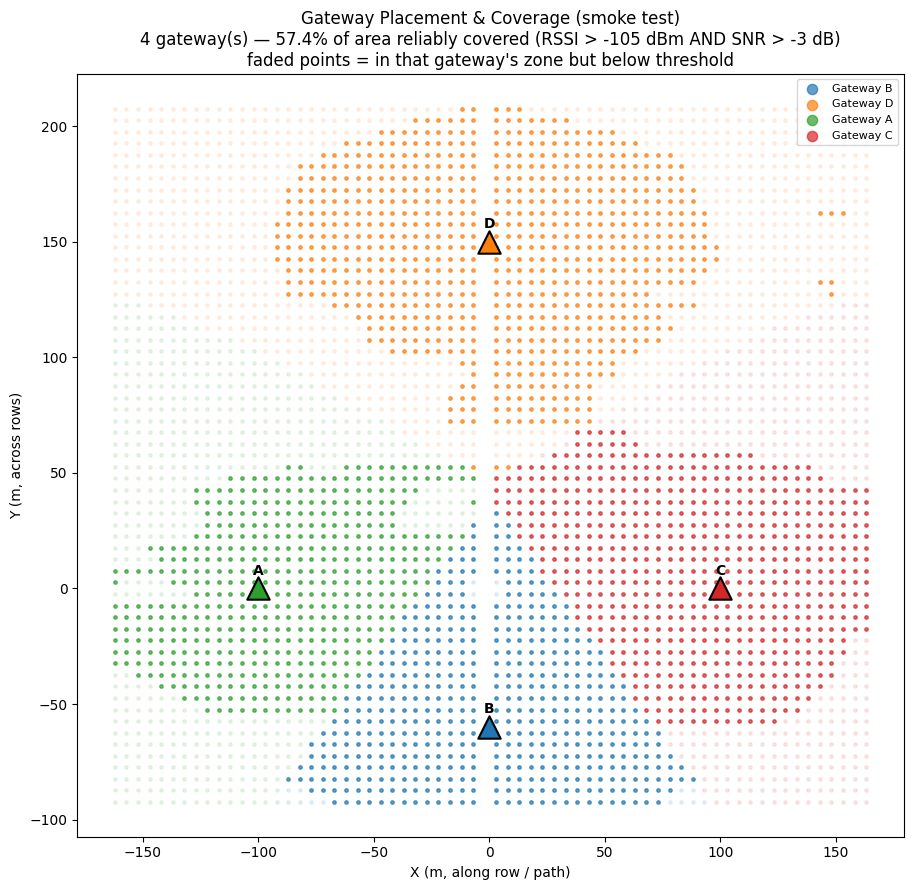

In [60]:
import matplotlib.pyplot as plt

# Demo using the smoke-test candidates/grid from above — swap in the real
# `selected`, `candidates_df`, `eval_grid` (and `cache`, for free reuse of
# already-computed predictions) once real candidate coordinates exist.
fig, ax = plot_gateway_coverage(selected, smoke_candidates_df, smoke_eval_grid,
                                 title="Gateway Placement & Coverage (smoke test)")
fig.savefig("gateway_coverage_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Optimal placement search: hexagonal covering + Lloyd's relaxation

Instead of ranking/greedily picking from a fixed candidate list, this searches for good positions directly: treat each gateway's coverage footprint as one fixed circle (justified below), then use the mathematically optimal way to cover a region with congruent circles at minimum overlap — a hexagonal lattice (Kershner, 1939) — refined with a few rounds of Lloyd's relaxation to fit the finite greenhouse footprint, then pruned/validated against the real fitted model.

**Why "one fixed circle" is a reasonable simplification here:** the row-crossing penalty in both path-loss fits is tiny relative to the log-distance term (β ≈ -0.025 dBm/crossing for RSSI, -0.067 dB/crossing for SNR, vs. ~-35 dBm and ~-10 dB per decade of distance). Dropping the small, position-dependent GPR residual bumps and using just the deterministic path-loss curve gives a footprint shape that only depends on the *relative* offset from the gateway — i.e. genuinely the same shape wherever you place it. The idealized circle is used only to *generate* candidate positions; achieved coverage is still checked against the real RSSI+SNR GPR model afterward.

In [61]:
def solve_effective_radius(coeffs, threshold, row_spacing=ROW_SPACING,
                            max_iter=50, tol=1e-6):
    """
    Solve for the distance R at which the deterministic path-loss
    prediction crosses `threshold`:
        threshold = intercept + log10_slope*log10(R) + crossing_slope*avg_crossings(R)
    row_crossings depends on direction (it's |dy|/row_spacing, not purely
    a function of R), so we use the direction-averaged crossings over a
    full circle of radius R: mean(|sin(theta)|) = 2/pi, giving
    avg_crossings(R) = (2/pi) * R / row_spacing. Solved by fixed-point
    iteration since crossings depends on R itself; crossing_slope is tiny
    so this converges in a couple of iterations.
    """
    intercept, log10_slope, crossing_slope = coeffs
    R = 10 ** ((threshold - intercept) / log10_slope)  # ignore crossings, first guess
    for _ in range(max_iter):
        avg_crossings = (2 / np.pi) * R / row_spacing
        R_new = 10 ** ((threshold - intercept - crossing_slope * avg_crossings) / log10_slope)
        if abs(R_new - R) < tol:
            R = R_new
            break
        R = R_new
    return R


R_rssi = solve_effective_radius(rssi_pathloss_coeffs, RSSI_THRESHOLD_DBM)
R_snr = solve_effective_radius(snr_pathloss_coeffs, SNR_THRESHOLD_DB)
R_eff = min(R_rssi, R_snr)
binding = "RSSI" if R_rssi < R_snr else "SNR"

print(f"RSSI-limited reliable radius : {R_rssi:.1f} m")
print(f"SNR-limited reliable radius  : {R_snr:.1f} m")
print(f"Effective coverage radius    : {R_eff:.1f} m  (binding constraint: {binding})")
print()
print("This is the deterministic path-loss-only radius — it ignores the GPR's")
print("local spatial structure and the z*std uncertainty margin used elsewhere")
print("in this notebook, so it's likely optimistic. Treat it as an initial")
print("guess for lattice spacing; the pipeline below re-checks real achieved")
print("coverage against the full fitted model — pass a smaller radius (e.g.")
print("R_eff * 0.8) into optimize_gateway_placement() if that comes up short.")

RSSI-limited reliable radius : 140.9 m
SNR-limited reliable radius  : 723.6 m
Effective coverage radius    : 140.9 m  (binding constraint: RSSI)

This is the deterministic path-loss-only radius — it ignores the GPR's
local spatial structure and the z*std uncertainty margin used elsewhere
in this notebook, so it's likely optimistic. Treat it as an initial
guess for lattice spacing; the pipeline below re-checks real achieved
coverage against the full fitted model — pass a smaller radius (e.g.
R_eff * 0.8) into optimize_gateway_placement() if that comes up short.


In [62]:
def generate_hex_lattice(x_min, x_max, y_min, y_max, radius, id_prefix="hex"):
    """
    Hexagonal lattice covering the bounding box with circles of the given
    radius. Kershner (1939): a hexagonal lattice with nearest-neighbor
    spacing R*sqrt(3) is the minimum-density regular covering of the plane
    by congruent circles of radius R — this directly minimizes overlap
    between gateway coverage areas while still covering everything.

    Padded by one radius beyond the box so edge/corner coverage isn't
    short; the padding intentionally overshoots — redundant points get
    pruned later against the real model.
    """
    d = radius * np.sqrt(3)      # nearest-neighbor spacing within a row
    row_spacing = 1.5 * radius   # vertical spacing between lattice rows

    pad = radius
    xs_start, xs_end = x_min - pad, x_max + pad
    ys_start, ys_end = y_min - pad, y_max + pad

    positions = []
    row = 0
    y = ys_start
    while y <= ys_end:
        x_offset = 0.0 if row % 2 == 0 else d / 2
        x = xs_start + x_offset
        while x <= xs_end:
            positions.append((x, y))
            x += d
        y += row_spacing
        row += 1

    lattice_df = pd.DataFrame(positions, columns=["x", "y"])
    lattice_df["candidate_id"] = [f"{id_prefix}_{i}" for i in range(len(lattice_df))]
    return lattice_df[["candidate_id", "x", "y"]]

In [63]:
def lloyd_relaxation(positions_df, region_points, n_iter=5):
    """
    Centroidal Voronoi Tessellation refinement (Lloyd's algorithm):
    repeatedly assign each region point to its nearest gateway (Euclidean
    distance — consistent with the "same circular footprint everywhere"
    assumption) and move each gateway to the centroid of its assigned
    points. Adapts the infinite-plane-optimal hex lattice to the actual
    (bounded, and here non-rectangular once the central path is excluded)
    greenhouse footprint. Gateways with no assigned points are left in
    place — pruned separately against the real model.
    """
    positions = positions_df[["x", "y"]].values.copy()
    region_xy = region_points[["x", "y"]].values

    for _ in range(n_iter):
        dists = cdist(region_xy, positions)
        assignment = dists.argmin(axis=1)

        new_positions = positions.copy()
        for i in range(len(positions)):
            mask = assignment == i
            if mask.sum() > 0:
                new_positions[i] = region_xy[mask].mean(axis=0)
        positions = new_positions

    out = positions_df.copy()
    out[["x", "y"]] = positions
    return out


def prune_redundant_gateways(candidates_df, eval_grid, cache=None,
                              rssi_threshold=RSSI_THRESHOLD_DBM,
                              snr_threshold=SNR_THRESHOLD_DB, z=1.645):
    """
    Drops any candidate that never wins as the best-RSSI server for a
    single eval_grid point once all candidates are considered together —
    i.e. fully redundant given the others. Checked against the REAL
    fitted RSSI+SNR model via compute_coverage_assignment (defined in
    section 7), not the idealized circle used to generate positions.
    """
    ids = candidates_df["candidate_id"].tolist()
    serving_idx, _ = compute_coverage_assignment(
        ids, candidates_df, eval_grid, cache=cache,
        rssi_threshold=rssi_threshold, snr_threshold=snr_threshold, z=z,
    )
    used_ids = set(np.array(ids)[np.unique(serving_idx[serving_idx >= 0])])
    kept = candidates_df[candidates_df["candidate_id"].isin(used_ids)].reset_index(drop=True)
    print(f"  pruned {len(candidates_df) - len(kept)} fully redundant candidate(s) "
          f"({len(candidates_df)} -> {len(kept)})")
    return kept

In [64]:
def optimize_gateway_placement(x_min, x_max, y_min, y_max, radius, search_grid,
                                n_rounds=4, lloyd_iters_per_round=5,
                                rssi_threshold=RSSI_THRESHOLD_DBM,
                                snr_threshold=SNR_THRESHOLD_DB, z=1.645):
    """
    Full pipeline: hex-lattice initial guess -> repeat {Lloyd's relaxation
    (idealized-circle/Euclidean, using search_grid) -> prune against the
    REAL fitted model} until the candidate count stabilizes.

    Use a coarse search_grid for speed (this recomputes real-model
    predictions every round) — re-validate/plot the returned candidates
    against your real, full-resolution eval_grid afterward.
    """
    candidates_df = generate_hex_lattice(x_min, x_max, y_min, y_max, radius)
    print(f"Initial hex lattice: {len(candidates_df)} candidates "
          f"(spacing {radius * np.sqrt(3):.1f} m)")

    for round_i in range(n_rounds):
        candidates_df = lloyd_relaxation(candidates_df, search_grid, n_iter=lloyd_iters_per_round)
        before = len(candidates_df)
        candidates_df = prune_redundant_gateways(
            candidates_df, search_grid,
            rssi_threshold=rssi_threshold, snr_threshold=snr_threshold, z=z,
        )
        print(f"Round {round_i + 1}: {before} -> {len(candidates_df)} candidates")
        if len(candidates_df) == before:
            print("Converged.")
            break

    candidates_df = candidates_df.copy()
    candidates_df["candidate_id"] = [f"opt_{i}" for i in range(len(candidates_df))]
    return candidates_df.reset_index(drop=True)


# Coarse search grid (5 m) for the relaxation/pruning loop — fast, since
# it recomputes real GPR predictions every round. Full eval_grid is used
# only once below, for final validation.
optimize_search_grid = make_evaluation_grid(
    X_MIN, X_MAX, Y_MIN, Y_MAX, resolution=5.0,
    exclude_x_range=(CENTRAL_PATH_X_MIN, CENTRAL_PATH_X_MAX),
)

optimized_candidates_df = optimize_gateway_placement(
    X_MIN, X_MAX, Y_MIN, Y_MAX, R_eff, optimize_search_grid,
)
print(f"\nFinal placement: {len(optimized_candidates_df)} gateway(s)")
print(optimized_candidates_df)

Initial hex lattice: 8 candidates (spacing 244.0 m)
  pruned 4 fully redundant candidate(s) (8 -> 4)
Round 1: 8 -> 4 candidates
  pruned 0 fully redundant candidate(s) (4 -> 4)
Round 2: 4 -> 4 candidates
Converged.

Final placement: 4 gateway(s)
  candidate_id     x      y
0        opt_0 -84.5  -17.4
1        opt_1  83.0  -19.9
2        opt_2 -84.5  135.1
3        opt_3  83.0  132.6


Real achieved coverage (report-grid, 2.5 m): 67.3% with 4 gateway(s)
If this is meaningfully below the idealized-circle expectation, R_eff
was optimistic (GPR uncertainty / local structure not captured by the
deterministic path-loss circle) — rerun optimize_gateway_placement with
a smaller radius, e.g. R_eff * 0.8, to tighten the lattice spacing.


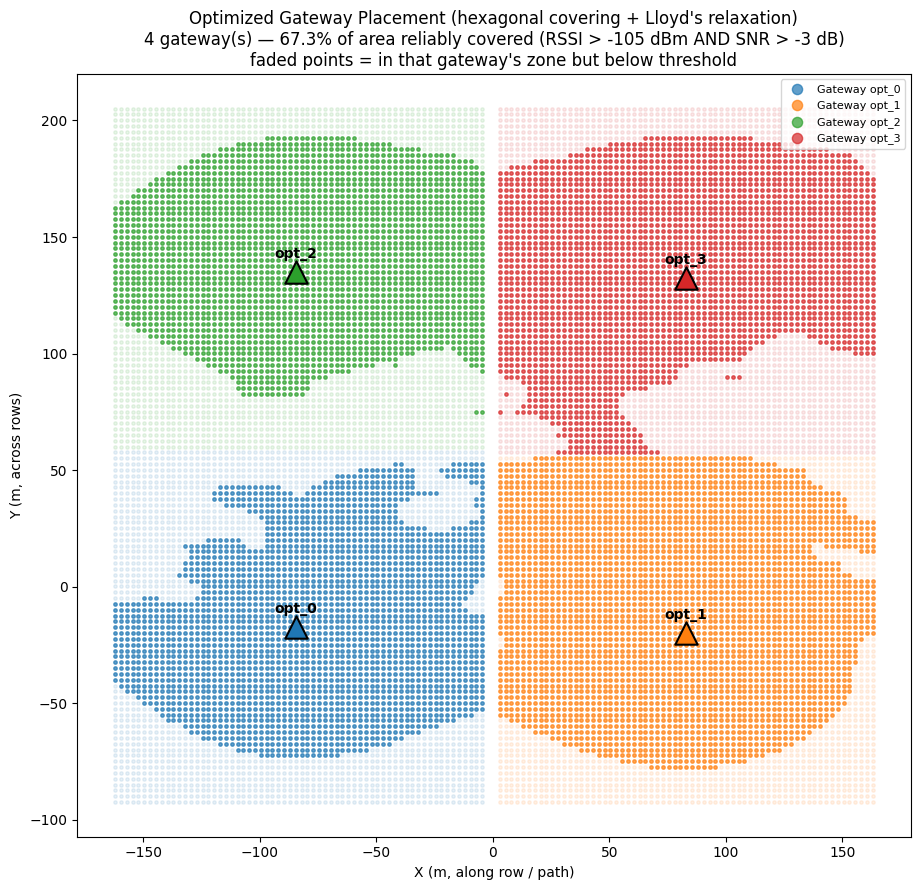

In [65]:
# Final validation against report_grid (2.5 m — see section 2) rather than
# the full 1 m eval_grid, which got too slow to check per-gateway once a
# search can return more than a handful of candidates.
optimized_ids = optimized_candidates_df["candidate_id"].tolist()
_, optimized_covered = compute_coverage_assignment(optimized_ids, optimized_candidates_df, report_grid)

print(f"Real achieved coverage (report-grid, {REPORT_RESOLUTION} m): {optimized_covered.mean():.1%} "
      f"with {len(optimized_ids)} gateway(s)")
print("If this is meaningfully below the idealized-circle expectation, R_eff")
print("was optimistic (GPR uncertainty / local structure not captured by the")
print("deterministic path-loss circle) — rerun optimize_gateway_placement with")
print("a smaller radius, e.g. R_eff * 0.8, to tighten the lattice spacing.")

fig, ax = plot_gateway_coverage(
    optimized_ids, optimized_candidates_df, report_grid,
    title="Optimized Gateway Placement (hexagonal covering + Lloyd's relaxation)",
)
fig.savefig("gateway_coverage_map_optimized.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Direct k-gateway search + auto-scan for a target coverage

Section 8's hex lattice is driven by the physics-derived radius, so the gateway count falls out wherever it converges (4, above) — it doesn't let you ask for a specific count. This section decouples the two: for any chosen k, seed k well-spread starting points (farthest-point sampling) and run the same Lloyd's relaxation as a k-means/CVT — the "radius" becomes whatever it needs to be for k gateways to split the greenhouse evenly. Then a scan wrapper increases k one at a time, checking REAL achieved coverage each time, and stops at whichever comes first: target coverage reached, marginal gain from one more gateway gets small, or a max-k cap.

In [66]:
def farthest_point_seeds(region_points, k, rng_seed=42):
    """
    Greedy k-center seeding: pick a random starting point, then repeatedly
    pick whichever remaining point is farthest from all points chosen so
    far. Gives well-spread initial gateway positions for any k, so Lloyd's
    relaxation converges quickly instead of starting from a clump.
    """
    rng = np.random.default_rng(rng_seed)
    xy = region_points[["x", "y"]].values
    n = len(xy)

    first_idx = rng.integers(n)
    chosen = [first_idx]
    min_dist_to_chosen = np.linalg.norm(xy - xy[first_idx], axis=1)

    for _ in range(k - 1):
        next_idx = np.argmax(min_dist_to_chosen)
        chosen.append(next_idx)
        dist_to_new = np.linalg.norm(xy - xy[next_idx], axis=1)
        min_dist_to_chosen = np.minimum(min_dist_to_chosen, dist_to_new)

    return xy[chosen]


def evaluate_k_gateways(k, search_grid, validation_grid, n_lloyd_iter=8,
                         rssi_threshold=RSSI_THRESHOLD_DBM,
                         snr_threshold=SNR_THRESHOLD_DB, z=1.645,
                         id_prefix="k", rng_seed=42):
    """
    Places exactly k gateways: farthest-point seeds -> Lloyd's relaxation
    (CVT) over search_grid -> real achieved coverage checked against
    validation_grid. Returns (candidates_df, coverage_fraction).
    """
    seeds = farthest_point_seeds(search_grid, k, rng_seed=rng_seed)
    candidates_df = pd.DataFrame({
        "candidate_id": [f"{id_prefix}{k}_{i}" for i in range(k)],
        "x": seeds[:, 0],
        "y": seeds[:, 1],
    })
    candidates_df = lloyd_relaxation(candidates_df, search_grid, n_iter=n_lloyd_iter)

    ids = candidates_df["candidate_id"].tolist()
    _, covered = compute_coverage_assignment(
        ids, candidates_df, validation_grid,
        rssi_threshold=rssi_threshold, snr_threshold=snr_threshold, z=z,
    )
    return candidates_df, covered.mean()


def scan_gateway_counts(search_grid, k_min=1, k_max=12,
                         target_coverage=0.90, min_marginal_gain=0.02,
                         n_lloyd_iter=8, rssi_threshold=RSSI_THRESHOLD_DBM,
                         snr_threshold=SNR_THRESHOLD_DB, z=1.645, rng_seed=42):
    """
    Increases gateway count k = k_min, k_min+1, ..., evaluating REAL
    achieved coverage each time, stopping at whichever comes first:
      - achieved coverage >= target_coverage (pass e.g. 0.999 for "full")
      - marginal gain (coverage(k) - coverage(k-1)) < min_marginal_gain
      - k == k_max

    Runs entirely on `search_grid` (pass a coarse grid for speed — this
    recomputes real-model predictions for every candidate at every k).
    Re-validate the returned candidates against your real, full-resolution
    eval_grid afterward, same as section 8.
    """
    results = []
    prev_coverage = 0.0
    best_candidates_df = None

    for k in range(k_min, k_max + 1):
        candidates_df, coverage = evaluate_k_gateways(
            k, search_grid, search_grid, n_lloyd_iter=n_lloyd_iter,
            rssi_threshold=rssi_threshold, snr_threshold=snr_threshold, z=z,
            rng_seed=rng_seed,
        )
        marginal_gain = coverage - prev_coverage
        results.append({"k": k, "coverage": coverage, "marginal_gain": marginal_gain})
        print(f"k={k}: coverage={coverage:.1%}  (+{marginal_gain:.1%} marginal)")

        best_candidates_df = candidates_df
        prev_coverage = coverage

        if coverage >= target_coverage:
            print(f"Reached target coverage ({target_coverage:.0%}).")
            break
        if k > k_min and marginal_gain < min_marginal_gain:
            print(f"Marginal gain ({marginal_gain:.1%}) below threshold "
                  f"({min_marginal_gain:.1%}) — stopping.")
            break
    else:
        print(f"Hit k_max={k_max} without reaching target coverage or a small marginal gain.")

    summary_df = pd.DataFrame(results)
    return best_candidates_df, summary_df

In [67]:
# Direct try: exactly 6 gateways (evaluated on the coarse search grid for speed)
six_candidates_df, six_coverage = evaluate_k_gateways(6, optimize_search_grid, optimize_search_grid)
print(f"k=6: {six_coverage:.1%} coverage (search-grid estimate)")

# Auto-scan: grow k until ~90% coverage, or marginal gain per extra
# gateway drops below 2%, or k_max=12 is hit — whichever comes first.
scan_candidates_df, scan_summary_df = scan_gateway_counts(
    optimize_search_grid, k_min=1, k_max=12,
    target_coverage=0.90, min_marginal_gain=0.02,
)
print("\nScan summary:")
print(scan_summary_df)

k=6: 73.2% coverage (search-grid estimate)
k=1: coverage=21.9%  (+21.9% marginal)
k=2: coverage=34.6%  (+12.7% marginal)
k=3: coverage=57.6%  (+23.0% marginal)
k=4: coverage=65.7%  (+8.1% marginal)
k=5: coverage=69.9%  (+4.3% marginal)
k=6: coverage=73.2%  (+3.2% marginal)
k=7: coverage=82.0%  (+8.8% marginal)
k=8: coverage=89.1%  (+7.1% marginal)
k=9: coverage=91.6%  (+2.5% marginal)
Reached target coverage (90%).

Scan summary:
   k  coverage  marginal_gain
0  1  0.219420       0.219420
1  2  0.346028       0.126608
2  3  0.575788       0.229760
3  4  0.656747       0.080958
4  5  0.699369       0.042623
5  6  0.731652       0.032282
6  7  0.819924       0.088272
7  8  0.891047       0.071122
8  9  0.916015       0.024968


Real achieved coverage (report-grid, 2.5 m): 92.0% with 9 gateway(s)


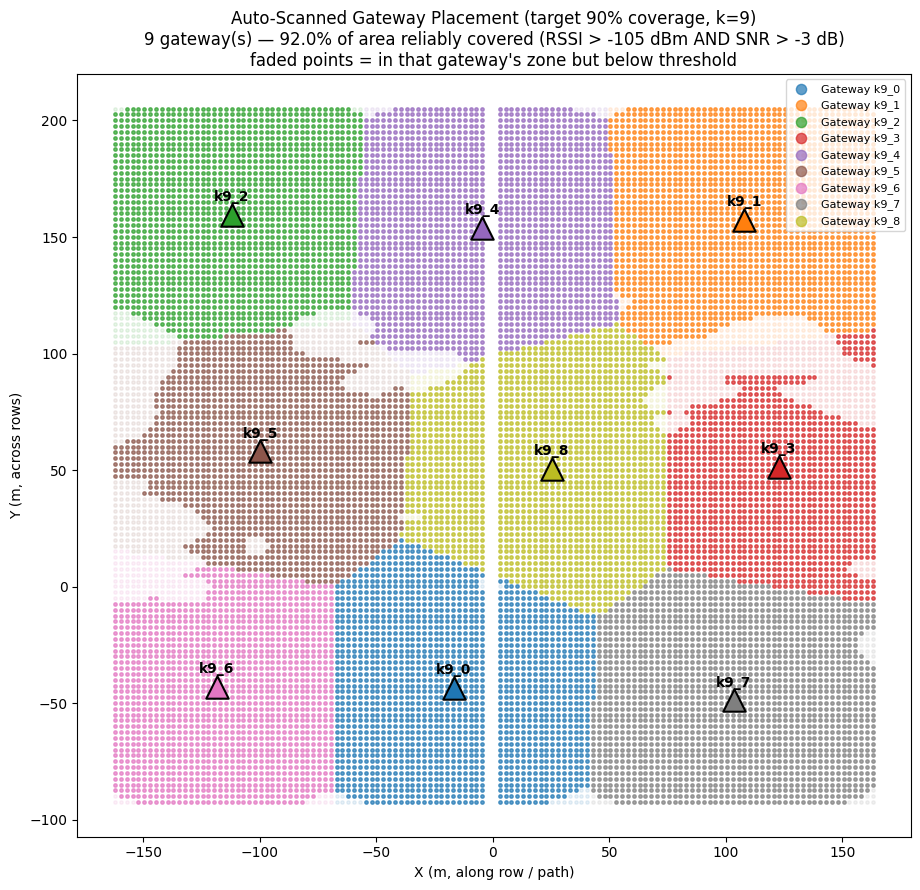

In [68]:
# Final validation against report_grid (2.5 m — see section 2), not the
# full 1 m eval_grid: with up to k_max=12 gateways from the scan, that was
# too many full-resolution GPR predicts (this is what timed out before).
scan_ids = scan_candidates_df["candidate_id"].tolist()
_, scan_covered = compute_coverage_assignment(scan_ids, scan_candidates_df, report_grid)

print(f"Real achieved coverage (report-grid, {REPORT_RESOLUTION} m): {scan_covered.mean():.1%} "
      f"with {len(scan_ids)} gateway(s)")

fig, ax = plot_gateway_coverage(
    scan_ids, scan_candidates_df, report_grid,
    title=f"Auto-Scanned Gateway Placement (target 90% coverage, k={len(scan_ids)})",
)
fig.savefig("gateway_coverage_map_scan.png", dpi=150, bbox_inches="tight")
plt.show()